# 06 · Powertrains and the PDT importer

outlap **never models electric machines internally** — that's a hard project firewall.
Powertrains enter exclusively as **`.ptm` maps**: torque/speed/efficiency tables in a neutral,
open format that any tool can emit. For users of the author's professional powertrain-design
toolchain ("PDT"), an importer reads its plain-HDF5 exports and distils them — including
collapsing a detailed thermal model into the two-node `.emotor` network the simulator uses.

Everything below runs on **synthetic** files shaped like PDT exports (the same generators the
test suite uses) — no proprietary data is in this repository, ever.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# Validated reference palette (light mode) — same style as the tour notebook.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

try:
    import ipywidgets as widgets  # noqa: F401

    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed - interactive panels are skipped "
          "(uv sync --group notebooks)")

import sys
import tempfile

import yaml

sys.path.insert(0, str(ROOT / "python" / "tests"))  # the repo's synthetic PDT generators
import pdt_fixtures  # noqa: E402

from outlap.importers.pdt_h5 import convert_batterypack, convert_edrive  # noqa: E402

_tmpdir = tempfile.TemporaryDirectory()  # held so it is cleaned up with the kernel
tmp = Path(_tmpdir.name)
pdt_fixtures.make_edrive_two_node(tmp / "edrive.h5", ns=14, nl=17)
convert_edrive(tmp / "edrive.h5", tmp / "motor.ptm.yaml", maps_path=tmp / "maps.parquet")
doc = yaml.safe_load((tmp / "motor.ptm.yaml").read_text())
print("emitted .ptm — kind:", doc["kind"])

emitted .ptm — kind: electric_machine


## The torque–speed map

The `.ptm` carries the peak-torque envelope plus dense loss/efficiency tables on a
speed × torque grid (sidecar Parquet). This is everything a lap simulator needs — and nothing
it doesn't:

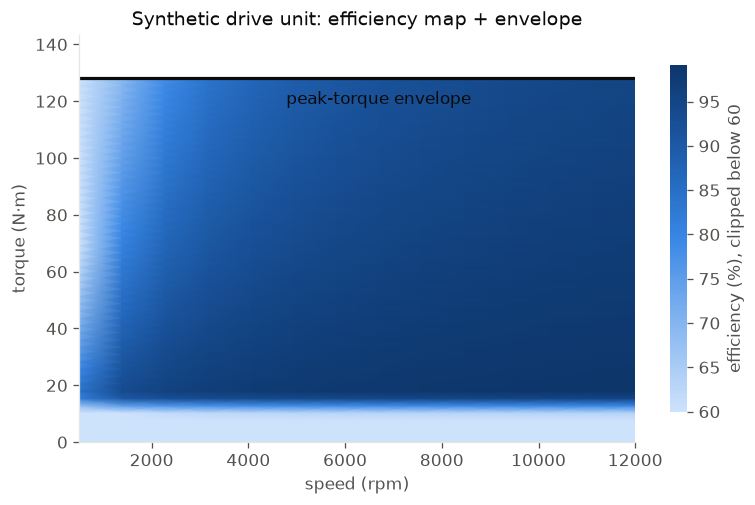

In [2]:
import pyarrow.parquet as pq

maps = pq.read_table(tmp / "maps.parquet")
cols = {name: maps.column(name).to_numpy() for name in maps.column_names}
spd, tq = cols["speed_rpm"], cols["torque_nm"]
eff = cols["efficiency"] * 100

ns, nl = len(np.unique(spd)), len(np.unique(tq))
S, T, E = spd.reshape(ns, nl), tq.reshape(ns, nl), eff.reshape(ns, nl)

env = doc["limits"]["max_torque_nm_vs_speed"]
env_s, env_t = np.array(env["speed_rpm"]), np.array(env["torque_nm"])

# Show the drive quadrant (torque ≥ 0); efficiency is meaningless at zero torque, so the
# colour scale starts where the map becomes interesting.
pos = T[0] >= 0
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.grid(False)
pc = ax.pcolormesh(S[:, pos], T[:, pos], E[:, pos], cmap=SEQ, shading="gouraud",
                   norm=mpl.colors.Normalize(60.0, float(eff.max())))
ax.plot(env_s, env_t, color=INK, lw=2.0)
ax.annotate("peak-torque envelope", (env_s[len(env_s) // 2], env_t[len(env_t) // 2]),
            xytext=(0, -16), textcoords="offset points", color=INK, ha="center")
ax.set_ylim(0, env_t.max() * 1.12)
ax.set_xlabel("speed (rpm)")
ax.set_ylabel("torque (N·m)")
ax.set_title("Synthetic drive unit: efficiency map + envelope")
cb = fig.colorbar(pc, ax=ax, shrink=0.85, label="efficiency (%), clipped below 60")
cb.outline.set_visible(False)
plt.show()

## Distilling thermal behaviour

PDT-grade machine models track ~19 thermal nodes; the simulator deliberately uses **two**
(winding + case, Decision #25). The importer *fits* that 2-node network to the detailed
model's overload envelopes, so community users get honest derating from a datasheet-sized
parameter set:

schema: emotor/1.0
nodes:
  winding:
    c_j_per_k: 661.11
    t_max_c: 180.0
    t_warn_c: 150.0
  case:
    c_j_per_k: 1223.57
    t_max_c: 120.0
    t_warn_c: 105.0
coupling:
  g_wc_w_per_k: 139.3351
  g_cool_w_per_k: 196.8441
cooling:
  liquid:
    coolant_temp_c: 65.0
loss_routing:
  winding_split: 0.7


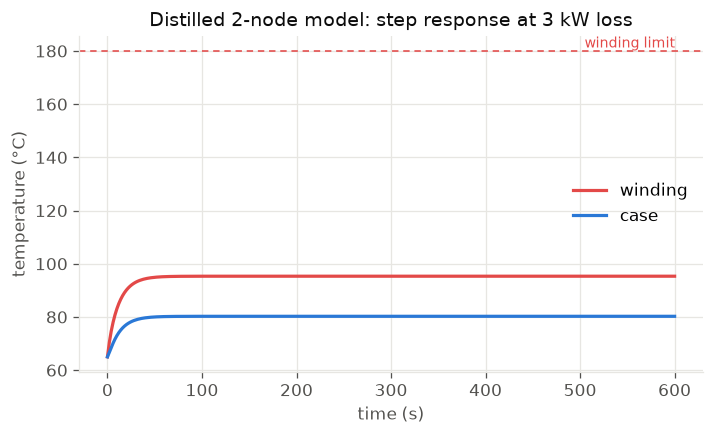

In [3]:
emotor = yaml.safe_load((tmp / "motor.ptm.emotor.yaml").read_text())
print("\n".join(yaml.safe_dump(emotor, sort_keys=False).splitlines()[:18]))

from outlap.importers.pdt_h5.thermal_fit import TwoNode  # noqa: E402

nodes = emotor["nodes"]
t_cool = emotor["cooling"]["liquid"]["coolant_temp_c"]
model = TwoNode(
    c_w=nodes["winding"]["c_j_per_k"],
    c_c=nodes["case"]["c_j_per_k"],
    g_wc=emotor["coupling"]["g_wc_w_per_k"],
    g_cool=emotor["coupling"]["g_cool_w_per_k"],
    s_w=emotor["loss_routing"]["winding_split"],
    alpha=0.0,  # copper feedback off for a clean linear step response
    t_ref=t_cool,
    t_cool=t_cool,
)

p_loss = 3000.0  # W of constant abuse
dt, steps = 2.0, 300
temps = np.empty((steps + 1, 2))
temps[0] = [t_cool, t_cool]
for i in range(steps):
    temps[i + 1] = model.transient(p_loss, dt, temps[i])
tgrid = np.arange(steps + 1) * dt

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.plot(tgrid, temps[:, 0], color=RED, label="winding")
ax.plot(tgrid, temps[:, 1], color=BLUE, label="case")
ax.axhline(nodes["winding"]["t_max_c"], color=RED, lw=1, ls=(0, (4, 3)))
ax.text(tgrid[-1], nodes["winding"]["t_max_c"], " winding limit", color=RED,
        fontsize=9, va="bottom", ha="right")
ax.set_xlabel("time (s)")
ax.set_ylabel("temperature (°C)")
ax.set_title(f"Distilled 2-node model: step response at {p_loss / 1000:.0f} kW loss")
ax.legend()
plt.show()

## The battery side

Battery packs come through the same door: OCV and resistance vs state-of-charge (and
temperature), pack limits, and capacity — the inputs to the equivalent-circuit model that
arrives with the ERS milestone:

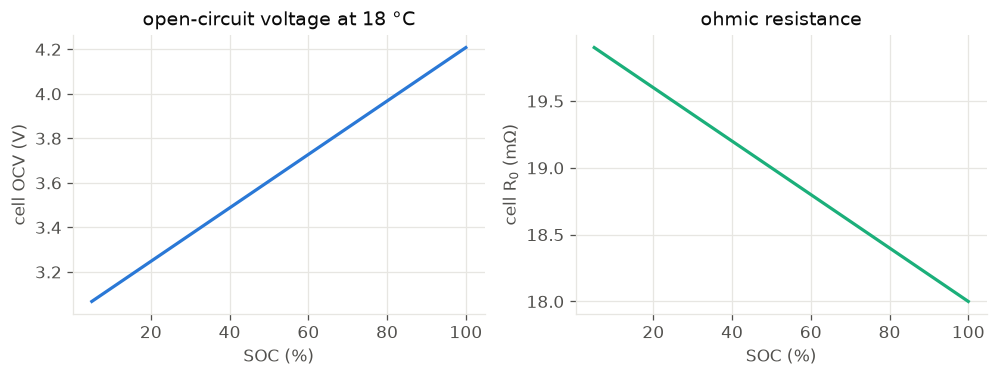

pack: 0.7 kWh · 13s3p · peak discharge 3 kW


In [4]:
pdt_fixtures.make_batterypack(tmp / "pack.h5")
summary = convert_batterypack(tmp / "pack.h5", tmp / "pack.yaml")
pack = yaml.safe_load((tmp / "pack.yaml").read_text())

cell_tab = pq.read_table(summary["tables"])
soc = cell_tab.column("soc").to_numpy()
temp_ax = cell_tab.column("temp_c").to_numpy()
mid_t = np.unique(temp_ax)[len(np.unique(temp_ax)) // 2]
at_t = temp_ax == mid_t
ocv = cell_tab.column("ocv_v").to_numpy()[at_t]
r0 = cell_tab.column("r0_ohm").to_numpy()[at_t]
soc_t = soc[at_t]

fig, (a, bx) = plt.subplots(1, 2, figsize=(8.8, 3.4))
a.plot(soc_t * 100, ocv, color=BLUE)
a.set_xlabel("SOC (%)")
a.set_ylabel("cell OCV (V)")
a.set_title(f"open-circuit voltage at {mid_t:.0f} °C")
bx.plot(soc_t * 100, r0 * 1000, color=AQUA)
bx.set_xlabel("SOC (%)")
bx.set_ylabel("cell R$_0$ (mΩ)")
bx.set_title("ohmic resistance")
plt.tight_layout()
plt.show()

lim = pack["limits"]["peak_discharge_power_w_vs_soc"]
print(f"pack: {pack['capacity']['e_pack_wh'] / 1000:.1f} kWh · "
      f"{pack['topology']['ns']}s{pack['topology']['np']}p · "
      f"peak discharge {max(lim['power_w']) / 1000:.0f} kW")

That closes the loop: **car, road, line, lap, tyre, and power — all data, all inspectable,
all validated.** The next milestones plug these together: the full quasi-steady-state tier
(T1) consumes the `.ptm` maps and the tyre curves directly, and the thermal/wear flagship
gives the tyre a temperature and a lifetime.